# QEC structures on Quantinuum Helios: syndrome extraction as LR-QAOA

This notebook benchmarks **syndrome extraction for a whole code** - every check of a surface, colour or
qLDPC code measured through an ancilla, mid-circuit, with feed-forward, round after round - on
Quantinuum's **Helios-1**. The code is only an input: load any set of checks as a Hamiltonian and the
same cells schedule it, write its Guppy program, price it with Nexus, submit it, collect the results and
compare them with the noiseless answer.

**Safe by default:** nothing is uploaded or sent until you set `SUBMIT = True`. Until then the notebook
runs the very same programs on a local simulator (Aer) for small codes, so the whole pipeline can be
checked for free. Those results are filed as `Helios-1_sim` and flagged `"simulated": true`.

**Requirements**
* `pip install -e ".[quantinuum]"` from the repository root (Guppy and `qnexus`), or keep the `sys.path`
  line of the next cell;
* for Helios, a Nexus account with access to the machine, logged in once with
  `import qnexus as qnx; qnx.login()`.

In [ ]:
import sys
from math import ceil
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
DATA, FIGURES = ROOT / "data", ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

from qecbench import codes
from qecbench.analysis import load_results
from qecbench.backends import QuantinuumBackend, code_instances
from qecbench.code_programs import guppy_source
from qecbench.experiment import build_plan, harvest, print_plan, submit
from qecbench.lrqaoa import ideal_r, random_baseline

## 0. Background

### From a code to a Hamiltonian

A code measured in the $Z$ basis is a set of **checks**. Check $c$ has a support $S_c$ of data qubits, and
the code becomes the Ising Hamiltonian

$$H = \sum_c w_c \prod_{i \in S_c} Z_i .$$

Its term for check $c$ is applied through an ancilla by exactly the syndrome-extraction gadget, with one
phase rotation added: `CX` from every support qubit onto the ancilla copies the parity, `RZ(2 w γ)`
imprints $e^{-i\gamma w_c Z\cdots Z}$, `H` and a **mid-circuit measurement** disentangle it, and when the
outcome is 1 **feed-forward** applies `Z` to the support. So one LR-QAOA layer is one round of syndrome
extraction, and depth $p$ is $p$ rounds. How much of the noiseless answer survives tells how a device
copes with that code's pattern of checks (their weights, overlaps and parallelism) before any
encoding or decoding. The **direct** reference applies the same term with no ancilla, as a `CX` ladder
onto the last support qubit, `RZ(2 w γ)` and the ladder undone: $2(|S_c| - 1)$ `CX`.

Nothing below depends on which code it is. A structure is only `n_data` and its weighted checks
(`qecbench.codes`), so a surface code, a colour code, a qLDPC code or any Hamiltonian you load runs
through the same scheduler, programs, backends and analysis:

| structure | built by | data qubits | checks |
|---|---|---|---|
| surface code | `codes.surface_code(d)` | $d^2$ | $(d-1)^2$ of weight 4, $2(d-1)$ of weight 2 |
| colour code (6.6.6) | `codes.color_code(d)` | $(3d^2+1)/4$ | weight 6 in the bulk, weight 4 on the boundary |
| qLDPC (bivariate bicycle) | `codes.bivariate_bicycle("BB18")`, also `BB24`, `BB30`, `BB48`, `GB16`, `GB26` | 18, 24, ... | independent rows of $H_X$ and $H_Z$, duplicates merged into weight 2 |
| anything else | `codes.from_hamiltonian(name, {(0, 1, 2): 1.0, ...})`, `codes.from_checks`, `codes.load(path)` | | |

`codes.load` reads a structure saved with `CodeStructure.save`, the `hamiltonian` block of an earlier
result file, or a text file with a `#n_qubits:<n>` header and one support per line (`[0, 6, 9, 11, 16]`,
optionally followed by a weight).

### What is measured

* **Approximation ratio** $r = (E_{\max} - \langle E\rangle)/(E_{\max} - E_{\min})$ with its shot-noise error.
  $E_{\min}$ is found exactly (integer programming): for the codes above every check can read $-1$ at once,
  so $E_{\min} = -\sum_c w_c$ and $E_{\max} = +\sum_c w_c$.
* **Random guessing** gives $r_{\rm rand} = 1/2$ exactly, with standard deviation
  $\sqrt{\sum_c w_c^2 / S}\,/\,(E_{\max} - E_{\min})$ at $S$ shots. $n_\sigma = (r - r_{\rm rand})/\sigma$ says
  whether a run carries any signal at all, with no simulation needed.
* **Noiseless reference** $r_{\rm ideal}(p)$, exact up to 25 data qubits (a statevector; above 20 qubits it
  takes seconds to minutes and is kept in `data/references/ideal_energies.json`). Above 25 there is no exact
  reference: a stored estimate is used if there is one, otherwise $r_{\rm ideal}$ and $r_{\rm ovl}$ are NaN
  and $n_\sigma$ is the measure.
* **Normalised quality** $r_{\rm ovl} = (r - r_{\rm rand})/(r_{\rm ideal} - r_{\rm rand})$: 1 is noiseless,
  0 is random.

### Schedules: which checks run together

Two checks that share a data qubit cannot be measured at the same time. `codes.schedule` colours the graph
of those conflicts (DSATUR) and gives **batches** of checks with disjoint supports, which run in parallel:
4 per round for the surface code, 3 for the colour code, 7 for BB18. Fewer batches means fewer
**idle qubit-steps** (data qubits waiting while a batch they are not part of runs), the count reported per
round below.

### Using all of Helios at once

Helios is all-to-all connected and reuses qubits, so there is no layout to choose: a structure is run on
**logical** labels, data qubits `0..n-1` (character $i$ of a result is data qubit $i$) and one ancilla label
per check. The program decides how the gadgets meet the machine.

The earlier programs measured the checks **one at
a time**: allocate an ancilla, entangle, measure, correct, then the next check. One round of the $d = 5$
surface code was 24 measure-and-correct steps in a row, with one of Helios-1's 8 operation zones busy and
every data qubit idling through the other 23.

Here each **batch** allocates all its ancillas together, applies the `CX` in rounds (the $j$-th support qubit
of every check at once), rotates them and reads the whole batch with **one** `measure_array`, then applies
the corrections. Within a batch the gadgets are independent, so Helios can run up to 8 of them side by side,
and a batch of $k$ checks takes about $\lceil k/8 \rceil$ steps. The $d = 5$ surface code needs 4 batches of at
most 8, i.e. about 4 steps per round instead of 24. Ancillas are freed when measured, so a program holds
`n_data + largest batch` qubits at once, which is also the size of a Helios-1E emulator request. A batch
never exceeds the qubits left free (`98 - n_data`); only then is a class of disjoint checks split.

The program is **generated as Guppy source**, one function per batch taking the layer's angle and a `main`
that calls them layer by layer. Guppy cannot index a compile-time list with a runtime loop variable, and
writing one function per batch keeps the program $p$ times smaller than spelling every layer out (the
91-qubit colour code at $p = 10$ compiles in about 13 s). A gate-for-gate Qiskit copy of the same plan
runs locally.

## 1. Configuration - the only cell you normally edit

* `BACKEND_NAME` - `"Helios-1"` (the machine) or `"Helios-1E"` (Quantinuum's hosted emulator with the Helios
  noise model, also billed in HQCs; its results are flagged as simulated).
* `SUBMIT` - `False` runs `LOCAL_STRUCTURES` on Aer; `True` uploads, quotes and sends `STRUCTURES`.
* `STRUCTURES` - `(family, size)` pairs: `("surface_code", d)`, `("color_code", d)`, `("qldpc", "BB18")`.
  `STRUCTURE_FILES` - any other structure, from files `codes.load` reads (section 0). Both are used.
* `DEPTHS`, `SHOTS`, `DELTA` - LR-QAOA depths, shots per program and ramp amplitude. Helios programs are
  costly; the defaults follow the earlier Helios-1 code runs ($p = 3, 5, 10$ at 50 shots).
* `KINDS` - which programs to run: `["mcm"]` (the syndrome-extraction gadgets), `["direct"]` (the same Hamiltonian
  with no ancilla, as `CX` ladders) or `["mcm", "direct"]`. Each kind is its own set of programs, so running both
  roughly doubles the cost; direct is the reference that separates the cost of measure-and-correct from that of
  the gates, and can be run in the same submission or on its own.
* `PROJECT` - the Nexus project jobs are filed under. `COST_MARGIN` - HQCs added to the Nexus prediction
  for each job's `max_cost`, the most the job may spend.

In [ ]:
BACKEND_NAME     = "Helios-1E"          # or "Helios-1E" (hosted emulator)
SUBMIT           = True               # True: upload, quote and send to Nexus
STRUCTURES       = [("surface_code", 3), ("color_code", 3), ("qldpc", "BB18")]
STRUCTURE_FILES  = []                  # e.g. [DATA / "codes" / "my_code.json"]
LOCAL_STRUCTURES = [("surface_code", 3), ("color_code", 3)]
DEPTHS           = [3, 5, 10]
SHOTS            = 50
DELTA            = 0.5
KINDS            = ["mcm"]             # "mcm", "direct", or both
PROJECT          = "Helios-Samples"    # If Nexus Project 
COST_MARGIN      = 3                   # HQC on top of the prediction, per job

## 2. Structures and their schedules

One row per structure: its checks, the batches of one round, the idle qubit-steps per round, and, for each
kind in `KINDS`, the qubits a program holds at once and its gates per layer. *Helios steps* is $\sum_b \lceil k_b / 8 \rceil$ over
the batches, against the *serial* steps (one per check) of measuring the checks one at a time.

With `SUBMIT = False` the backend is `Helios-1_sim`, which runs each program on Aer, noiseless. Aer
simulates a program with mid-circuit measurements shot by shot, so the local rehearsal is limited to
programs of about 20 qubits.

In [ ]:
backend = QuantinuumBackend(BACKEND_NAME, local=not SUBMIT, project=PROJECT, cost_margin=COST_MARGIN, seed=7)
structures = [codes.build(family, size) for family, size in (STRUCTURES if SUBMIT else LOCAL_STRUCTURES)]
structures += [codes.load(path) for path in STRUCTURE_FILES]
kinds = tuple(dict.fromkeys(KINDS))
assert kinds and set(kinds) <= {"mcm", "direct"}, f"KINDS must be 'mcm', 'direct' or both, got {KINDS}"
schedules = {s.name: backend.code_schedule(s) for s in structures}

print(f"backend {backend.name}, kinds {', '.join(kinds)}" + (f"  ({backend.noise_description})" if backend.simulated else ""))
header = (f"\n{'structure':>14} {'data':>5} {'checks':>18} {'batches':>8} {'largest':>8} {'idle':>5} {'Helios':>7} "
          f"{'serial':>7}")
for kind in kinds:
    header += f" | {kind}: {'qubits':>6} {'CX':>5}" + (f" {'MCM':>5}" if kind == "mcm" else "")
print(header)
for s in structures:
    sched = schedules[s.name]
    steps = sum(ceil(len(b) / backend.zones) for b in sched.batches)
    weights = ", ".join(f"{c}xw{w}" for w, c in s.check_weights.items())
    row = (f"{s.name:>14} {s.n_data:>5} {weights:>18} {sched.n_batches:>8} {sched.max_batch:>8} "
           f"{sched.idle_qubit_steps():>5} {steps:>7} {s.n_checks:>7}")
    for kind in kinds:
        counts = s.counts(kind)
        row += (f" | {'':>{len(kind) + 1}} {sched.peak_qubits(kind):>6} {counts['two_qubit_gates']:>5}"
                + (f" {counts['mid_circuit_measurements']:>5}" if kind == "mcm" else ""))
    print(row)

too_big = [s.name for s in structures if max(schedules[s.name].peak_qubits(k) for k in kinds) > 22]
if not SUBMIT and too_big:
    raise ValueError(f"{too_big}: too large for the local rehearsal on Aer; use smaller LOCAL_STRUCTURES")
instances = [inst for s in structures for inst in code_instances(s, kinds)]

backend Helios-1E, kinds mcm  (Helios-1E: Quantinuum's hosted emulator and its Helios noise model)

     structure  data             checks  batches  largest  idle  Helios  serial | mcm: qubits    CX   MCM
    surface_d3     9         4xw2, 4xw4        4        3    12       4       8 |          12    24     8
      color_d3     7               3xw4        3        1     9       3       3 |           8    12     3
          BB18    18              14xw5        7        2    56       7      14 |          20    70    14


The generated program (of the first kind in `KINDS`) of the smallest structure with more than one check per
batch, at $p = 2$, as it is sent: one function per batch, then `main`. Every other structure and depth is written the same way.

In [ ]:
example = min(structures, key=lambda s: (schedules[s.name].max_batch == 1, s.n_data))
print(guppy_source(example, schedules[example.name], depth=2, delta=DELTA, kind=kinds[0]))

"""Generated by qecbench.code_programs: LR-QAOA on surface_d3 (mcm), p = 2, delta = 0.5."""
from guppylang import guppy
from guppylang.std.angles import angle
from guppylang.std.builtins import array, result
from guppylang.std.quantum import collect_measurements, cx, h, measure_array, qubit, rx, rz, z


@guppy
def batch_0(qs: array[qubit, 9], halfturns: float) -> None:
    anc = array(qubit() for _ in range(3))
    cx(qs[0], anc[0])
    cx(qs[6], anc[1])
    cx(qs[5], anc[2])
    cx(qs[1], anc[0])
    cx(qs[7], anc[1])
    cx(qs[8], anc[2])
    cx(qs[3], anc[0])
    cx(qs[4], anc[0])
    rz(anc[0], angle(halfturns * 1.0))
    h(anc[0])
    rz(anc[1], angle(halfturns * 1.0))
    h(anc[1])
    rz(anc[2], angle(halfturns * 1.0))
    h(anc[2])
    m = collect_measurements(measure_array(anc))
    if m[0]:
        z(qs[0])
        z(qs[1])
        z(qs[3])
        z(qs[4])
    if m[1]:
        z(qs[6])
        z(qs[7])
    if m[2]:
        z(qs[5])
        z(qs[8])

@guppy
def batch_1(qs: ar

## 3. What to expect - before spending anything

For each structure and depth: the noiseless $r_{\rm ideal}$, and the random-guessing mean with the $3\sigma$
threshold at `SHOTS`. A run can only be told apart from random guessing if it lands above that
threshold, so a noiseless $r_{\rm ideal}$ below it means the configured shots cannot resolve that point even on a
perfect device. Above 25 data qubits $r_{\rm ideal}$ is NaN unless a reference is stored.

In [ ]:
print(f"{'structure':>14} {'p':>4} {'r_ideal':>8} {'random + 3 sigma':>17}")
for s in structures:
    patch = code_instances(s, ("mcm",))[0]
    r_rand, sigma = random_baseline(patch, SHOTS)
    for p in DEPTHS:
        print(f"{s.name:>14} {p:>4} {ideal_r(patch, p, DELTA):>8.3f} {r_rand + 3 * sigma:>17.3f}")

     structure    p  r_ideal  random + 3 sigma
    surface_d3    3    0.774             0.575
    surface_d3    5    0.816             0.575
    surface_d3   10    0.861             0.575
      color_d3    3    0.809             0.622
      color_d3    5    0.863             0.622
      color_d3   10    0.938             0.622
          BB18    3    0.574             0.557
          BB18    5    0.665             0.557
          BB18   10    0.791             0.557


## 4. Plan and cost

One program per structure, kind and depth. With `SUBMIT = True` the programs are compiled and uploaded to
Nexus, which predicts their cost in HQCs. Uploading costs nothing and runs nothing. The prediction sets each
job's `max_cost`, with `COST_MARGIN` on top. Up to 16 programs go into one job.

In [ ]:
plan = build_plan(backend, instances, depths=DEPTHS, shots=SHOTS, delta=DELTA)
if SUBMIT:
    backend.quote(plan)
print_plan(plan, backend)

Backend    : Helios-1E (quantinuum)
Sweep      : depths [3, 5, 10], 50 shots per circuit, delta 0.5
Instances  : 3 in total, 24 qubits benchmarked as ancilla
  mcm    : 1 x BB18 of 18 data qubits, 1 x color_d3 of 7 data qubits, 1 x surface_d3 of 9 data qubits
           3 circuit(s) per depth, running 1 + 1 + 1 instances in parallel
Circuits   : 9 = 3 depths x 3 circuits per depth
Jobs       : 1, up to 9 circuit(s) each

 depth     kind  circuits  instances        HQC
-----------------------------------------------
     3      mcm         3          3      68.00
     5      mcm         3          3     100.00
    10      mcm         3          3     179.00
-----------------------------------------------
          TOTAL         9                347.00
  note: predicted by Nexus (qnx.hugr.cost_confidence) for the uploaded programs
  note: each job's max_cost = ceil(predicted) + 3 HQC


## 5. Submit

Writes a **manifest** (`data/manifests/<backend>/`) after every job, so the job ids survive an interrupted
session. With `SUBMIT = False` this runs the local simulation instead and costs nothing.

In [ ]:
manifest = submit(plan, backend, manifest_dir=DATA / "manifests")

SIMULATING 9 circuits to Helios-1E in 1 job(s), which on the device would cost 347.00 HQC
  job 1: 9 circuit(s) -> 08ad4d80-5a37-490a-93df-3b3a6bdc14bb
manifest: data/manifests/Helios-1E/20260917_135420_Helios-1E_BB18-color_d3-surface_d3.json


## 6. Harvest

Needs only the manifest, so it can run hours later in a new session. Unfinished jobs are reported and
skipped; running the cell again adds what has finished since. Results go to
`data/results/<backend>/<family>/<kind>/` (e.g. `Helios-1/surface_code/mcm/`), one file per run, and each
result keeps the full structure it ran, so it can be analysed without this notebook.

In [ ]:
manifests = sorted((DATA / "manifests" / backend.name).glob("*.json"), key=lambda p: p.name)
assert manifests, "no manifest yet - run the submit cell first"
manifest_path = manifests[-1]
print("harvesting", manifest_path.name)
saved = harvest(manifest_path, backend, data_dir=DATA / "results")

harvesting 20260917_135420_Helios-1E_BB18-color_d3-surface_d3.json


Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will om

9 results written to 3 run file(s) under data/results, 0 already there


## 7. Results

The table lists, per structure, kind and depth, $r$ with its shot-noise error, $r_{\rm ideal}$, $r_{\rm ovl}$ and
$n_\sigma$ above random guessing. The figure has one panel per structure: $r$ against depth for each kind in `KINDS`, MCM (crosses)
and direct (circles), the noiseless curve (black) where it exists, and the random-guessing band
$1/2 \pm 3\sigma$ (grey).

     structure    kind    p               r  r_ideal   r_ovl  n_sigma
      color_d3     mcm    3   0.780 ± 0.035    0.809   0.907      6.9
      color_d3     mcm    5   0.847 ± 0.026    0.863   0.955      8.5
      color_d3     mcm   10   0.913 ± 0.025    0.938   0.944     10.1
          BB18     mcm    3   0.561 ± 0.029    0.574   0.835      3.3
          BB18     mcm    5   0.730 ± 0.027    0.665   1.392     12.2
          BB18     mcm   10   0.730 ± 0.031    0.791   0.789     12.2
    surface_d3     mcm    3   0.765 ± 0.019    0.774   0.968     10.6
    surface_d3     mcm    5   0.797 ± 0.017    0.816   0.943     11.9
    surface_d3     mcm   10   0.833 ± 0.018    0.861   0.920     13.3


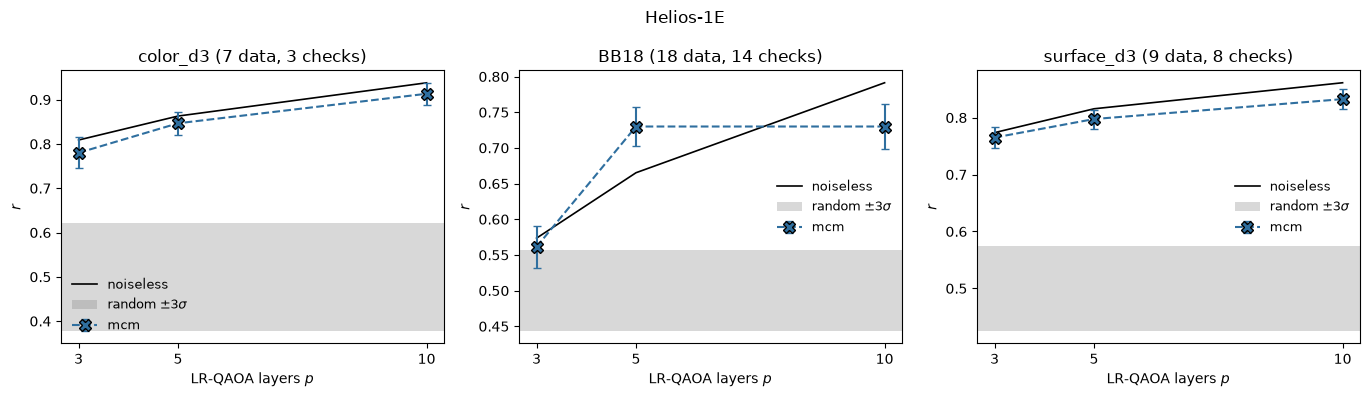

In [ ]:
runs = {kind: load_results(DATA / "results", backend.name, kind=kind, manifest_path=manifest_path) for kind in kinds}
by_structure = {}
for kind, res in runs.items():
    for patch, by_depth in res.items():
        by_structure.setdefault(patch.code.name, {})[kind] = (patch, by_depth)

print(f"{'structure':>14} {'kind':>7} {'p':>4} {'r':>15} {'r_ideal':>8} {'r_ovl':>7} {'n_sigma':>8}")
for name, per_kind in by_structure.items():
    for kind, (patch, by_depth) in per_kind.items():
        for p, s in sorted(by_depth.items()):
            print(f"{name:>14} {kind:>7} {p:>4} {s['r']:>7.3f} ± {s['r_err']:.3f} {s['r_ideal']:>8.3f} "
                  f"{s['r_ovl']:>7.3f} {s['n_sigmas']:>8.1f}")

fig, axes = plt.subplots(1, len(by_structure), figsize=(4.6 * len(by_structure), 4), squeeze=False)
for ax, (name, per_kind) in zip(axes[0], by_structure.items()):
    patch = next(iter(per_kind.values()))[0]
    grid = sorted({p for _, by in per_kind.values() for p in by})
    ideal = [ideal_r(patch, p, DELTA) for p in grid]
    if np.isfinite(ideal).all():
        ax.plot(grid, ideal, "-", color="black", lw=1.2, label="noiseless")
    sigma = random_baseline(patch, SHOTS)[1]
    ax.axhspan(0.5 - 3 * sigma, 0.5 + 3 * sigma, color="gray", alpha=0.3, lw=0, label=r"random $\pm 3\sigma$")
    for kind, (_, by_depth) in per_kind.items():
        ps = sorted(by_depth)
        ax.errorbar(ps, [by_depth[p]["r"] for p in ps], yerr=[by_depth[p]["r_err"] for p in ps],
                    fmt="X--" if kind == "mcm" else "o-", ms=8, mec="black", capsize=3,
                    color="#2f6f9f" if kind == "mcm" else "#b8560f", label=kind)
    ax.set(title=f"{name} ({patch.code.n_data} data, {patch.code.n_checks} checks)", xlabel="LR-QAOA layers $p$",
           ylabel="$r$", xticks=grid)
    ax.legend(fontsize=9, frameon=False)
fig.suptitle(backend.name)
fig.tight_layout()
fig.savefig(FIGURES / f"{backend.name}_codes_r_vs_p.pdf", bbox_inches="tight")
plt.show()
if not SUBMIT:
    print("(local, noiseless simulation: r should follow the noiseless curve within shot noise)")